# Filtered State Summaries

This notebook loads the filtered state paths from the paired Normal SABR and Rough-SABR runs and creates summary tables and diagnostic figures.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    return here.parent if here.name == "notebooks" else here


def project_relative(path: Path) -> str:
    path = Path(path).resolve()
    try:
        return str(path.relative_to(PROJECT_ROOT)).replace(chr(92), "/")
    except ValueError:
        return str(path)


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
COMPARISON_ROOT = OUTPUT_ROOT / "comparisons" / "filtered_state_summaries"
TABLE_DIR = COMPARISON_ROOT / "tables"
FIGURE_DIR = COMPARISON_ROOT / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NORMAL_PREFIX = "normal_sabr_400ts_no_A_RW_seed"
ROUGH_PREFIX = "rough_sabr_400ts_logU0_seed"
SEEDS = [123, 456, 789, 101112, 131415]
PRIMARY_SEED = 123


## Load State Paths

Load the filtered state paths by model and seed, then add the observed forward proxy for comparison.


In [2]:
def load_state_paths(model_prefix: str, model_name: str) -> pd.DataFrame:
    parts = []
    for seed in SEEDS:
        path = OUTPUT_ROOT / f"{model_prefix}{seed}" / "filtered_state_path.csv"
        if not path.exists():
            print("Missing:", project_relative(path))
            continue
        h = pd.read_csv(path)
        h.insert(0, "seed", seed)
        h.insert(1, "model", model_name)
        parts.append(h)
    return pd.concat(parts, ignore_index=True)


def load_forward_proxy() -> pd.DataFrame:
    parts = []
    for seed in SEEDS:
        path = OUTPUT_ROOT / f"{NORMAL_PREFIX}{seed}" / "selected_observations.csv"
        if not path.exists():
            continue
        h = pd.read_csv(path, usecols=["t_index", "F_obs"])
        h = h.groupby("t_index", as_index=False)["F_obs"].median()
        h.insert(0, "seed", seed)
        parts.append(h)
    return pd.concat(parts, ignore_index=True)

normal_states = load_state_paths(NORMAL_PREFIX, "Normal")
rough_states = load_state_paths(ROUGH_PREFIX, "Rough")
forward_proxy = load_forward_proxy()

state_paths = pd.concat([normal_states, rough_states], ignore_index=True, sort=False)
state_paths = state_paths.merge(forward_proxy, on=["seed", "t_index"], how="left")
state_paths["F_error_vs_obs"] = state_paths["F"] - state_paths["F_obs"]
state_paths["abs_F_error_vs_obs"] = state_paths["F_error_vs_obs"].abs()
state_paths["vol_level_proxy"] = state_paths["atm_logvol_proxy"]
state_paths["memory_norm_for_plot"] = state_paths.get("memory_norm", np.nan)

state_paths.to_csv(TABLE_DIR / "filtered_state_paths_paired.csv", index=False)
display(state_paths.head())


,seed,model,F,F_std,A,A_std,rho,rho_std,nu,nu_std,beta,beta_std,atm_logvol_proxy,atm_logvol_proxy_std,capture_time_utc,t_index,dt_years,ess,pre_update_ess,log_predictive_likelihood,avg_log_predictive_likelihood_per_quote,log_predictive_likelihood_with_forward_anchor,avg_log_predictive_likelihood_with_forward_anchor_per_quote,min_tempered_ess,n_tempering_steps,n_tempering_resamples,n_options,n_priced,mean_market_price,median_price_sd,fit_price_rmse,fit_inside_bidask_rate,fit_mean_abs_price_residual,U,U_std,H,H_std,rough_driver,rough_driver_std,memory_norm,rough_variance,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,elapsed_years,F_obs,F_error_vs_obs,abs_F_error_vs_obs,vol_level_proxy,memory_norm_for_plot
0,123,Normal,76705.405707,23.932336,9.898701,0.120339,-0.513869,0.103484,1.072104,0.287820,0.7,0.000000e+00,0.338946,0.004134,2026-05-26T13:25:12+0000,0,0.000000,284.872663,300.000000,-29.076856,-0.377622,-29.176110,-0.378911,210.0,8,7,77.0,77.0,0.078135,0.000525,0.001489,0.500000,0.000970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76767.93,-62.524293,62.524293,0.338946,NaN
1,123,Normal,76695.965475,59.315654,9.856878,0.066728,-0.500527,0.131679,1.167922,0.271398,0.7,1.110223e-16,0.337527,0.002328,2026-05-26T13:30:12+0000,1,0.000010,216.511055,284.872663,-27.085472,-0.351759,-27.262555,-0.354059,210.0,6,5,77.0,77.0,0.074300,0.000530,0.001645,0.480000,0.001001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76752.84,-56.874525,56.874525,0.337527,NaN
2,123,Normal,76552.564455,59.485166,9.901175,0.118252,-0.260283,0.162248,1.624489,0.405914,0.7,0.000000e+00,0.339233,0.004013,2026-05-26T13:33:28+0000,2,0.000006,256.541182,216.511055,-28.090673,-0.364814,-28.744684,-0.373308,210.0,6,5,77.0,77.0,0.070416,0.000500,0.003190,0.320000,0.001930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76705.32,-152.755545,152.755545,0.339233,NaN
3,123,Normal,76637.086677,12.837510,9.868956,0.040416,-0.203718,0.030109,1.818568,0.043902,0.7,0.000000e+00,0.338018,0.001399,2026-05-26T13:38:28+0000,3,0.000010,219.317483,256.541182,-20.548600,-0.266865,-21.468158,-0.278807,210.0,6,5,77.0,77.0,0.083552,0.000962,0.002710,0.302632,0.001978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76844.57,-207.483323,207.483323,0.338018,NaN
4,123,Normal,76698.073350,39.252137,9.844201,0.033489,-0.211605,0.032438,1.812067,0.046753,0.7,0.000000e+00,0.337089,0.001148,2026-05-26T13:43:28+0000,4,0.000010,270.307536,219.317483,-23.818562,-0.309332,-24.566708,-0.319048,210.0,6,5,77.0,77.0,0.077311,0.000750,0.002908,0.276316,0.001981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76883.74,-185.666650,185.666650,0.337089,NaN


## State Summary Table

Summarize the main filtered state variables by model.


In [3]:
summary_rows = []
for model, h in state_paths.groupby("model"):
    row = {
        "model": model,
        "n_seed_timestamp_obs": len(h),
        "mean_abs_F_error": h["abs_F_error_vs_obs"].mean(),
        "median_abs_F_error": h["abs_F_error_vs_obs"].median(),
        "mean_atm_logvol_proxy": h["atm_logvol_proxy"].mean(),
        "std_atm_logvol_proxy": h["atm_logvol_proxy"].std(),
        "mean_rho": h["rho"].mean(),
        "std_rho": h["rho"].std(),
        "mean_nu": h["nu"].mean(),
        "std_nu": h["nu"].std(),
        "mean_beta": h["beta"].mean(),
        "std_beta": h["beta"].std(),
        "mean_fit_rmse": h["fit_price_rmse"].mean(),
    }
    if "memory_norm" in h:
        row["mean_memory_norm"] = h["memory_norm"].mean()
        row["std_memory_norm"] = h["memory_norm"].std()
    summary_rows.append(row)

state_summary = pd.DataFrame(summary_rows)
state_summary.to_csv(TABLE_DIR / "filtered_state_summary_by_model.csv", index=False)
display(state_summary.round(6))


,model,n_seed_timestamp_obs,mean_abs_F_error,median_abs_F_error,mean_atm_logvol_proxy,std_atm_logvol_proxy,mean_rho,std_rho,mean_nu,std_nu,mean_beta,std_beta,mean_fit_rmse,mean_memory_norm,std_memory_norm
0,Normal,2000,63.898660,52.035361,0.347184,0.006519,-0.370477,0.114901,1.658241,0.527069,0.7,0.0,0.001833,NaN,NaN
1,Rough,2000,54.551584,43.076985,0.342558,0.006900,-0.319151,0.053944,1.053410,0.087540,0.7,0.0,0.001747,0.024706,0.015689


## Seed-Averaged State Paths

Plot the filtered forward, ATM log-volatility proxy, rho, and nu after averaging across seeds.


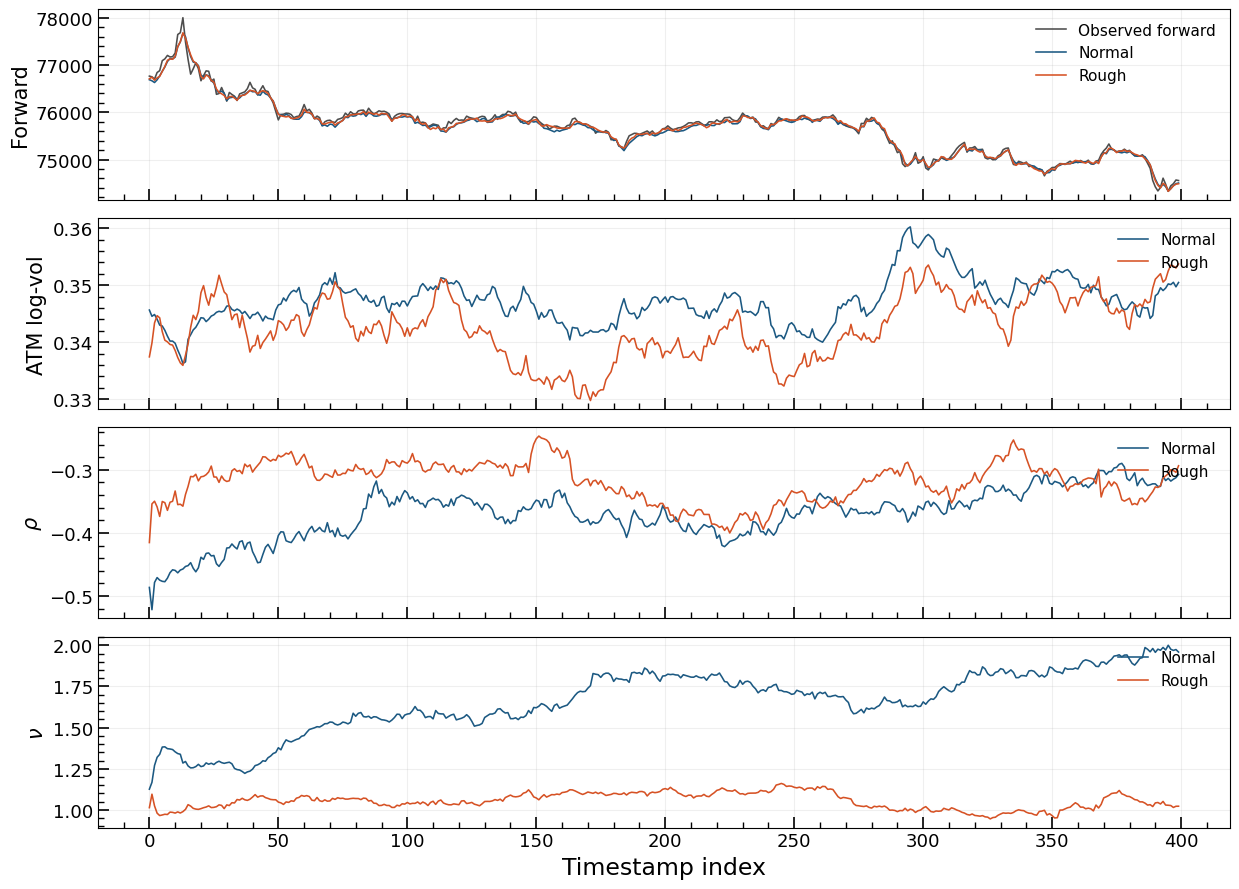

Saved: outputs/comparisons/filtered_state_summaries/figures/filtered_state_interpretable_paths_across_seeds.png


In [4]:
timestamp_summary = (
    state_paths.groupby(["model", "t_index"], as_index=False)
    .agg(
        F_mean=("F", "mean"),
        F_std=("F", "std"),
        F_obs_mean=("F_obs", "mean"),
        atm_logvol_proxy_mean=("atm_logvol_proxy", "mean"),
        atm_logvol_proxy_std=("atm_logvol_proxy", "std"),
        rho_mean=("rho", "mean"),
        rho_std=("rho", "std"),
        nu_mean=("nu", "mean"),
        nu_std=("nu", "std"),
        beta_mean=("beta", "mean"),
        beta_std=("beta", "std"),
        fit_price_rmse_mean=("fit_price_rmse", "mean"),
    )
)
timestamp_summary.to_csv(TABLE_DIR / "filtered_state_paths_across_seed_summary.csv", index=False)

normal_ts = timestamp_summary[timestamp_summary["model"] == "Normal"].sort_values("t_index")
rough_ts = timestamp_summary[timestamp_summary["model"] == "Rough"].sort_values("t_index")
forward_ts = state_paths.groupby("t_index", as_index=False)["F_obs"].mean()

normal_color = "#1c5982"
rough_color = "#d65225"
obs_color = "0.30"

fig, axes = plt.subplots(4, 1, figsize=(12.5, 9.0), sharex=True)

axes[0].plot(forward_ts["t_index"], forward_ts["F_obs"], color=obs_color, linewidth=1.15, label="Observed forward")
axes[0].plot(normal_ts["t_index"], normal_ts["F_mean"], color=normal_color, linewidth=1.15, label="Normal")
axes[0].plot(rough_ts["t_index"], rough_ts["F_mean"], color=rough_color, linewidth=1.15, label="Rough")
axes[0].set_ylabel("Forward", fontsize=15)
axes[0].legend(loc="upper right", frameon=False, fontsize=11)

axes[1].plot(normal_ts["t_index"], normal_ts["atm_logvol_proxy_mean"], color=normal_color, linewidth=1.15, label="Normal")
axes[1].plot(rough_ts["t_index"], rough_ts["atm_logvol_proxy_mean"], color=rough_color, linewidth=1.15, label="Rough")
axes[1].set_ylabel("ATM log-vol", fontsize=15)
axes[1].legend(loc="upper right", frameon=False, fontsize=11)

axes[2].plot(normal_ts["t_index"], normal_ts["rho_mean"], color=normal_color, linewidth=1.15, label="Normal")
axes[2].plot(rough_ts["t_index"], rough_ts["rho_mean"], color=rough_color, linewidth=1.15, label="Rough")
axes[2].set_ylabel(r"$\rho$", fontsize=15)
axes[2].legend(loc="upper right", frameon=False, fontsize=11)

axes[3].plot(normal_ts["t_index"], normal_ts["nu_mean"], color=normal_color, linewidth=1.15, label="Normal")
axes[3].plot(rough_ts["t_index"], rough_ts["nu_mean"], color=rough_color, linewidth=1.15, label="Rough")
axes[3].set_ylabel(r"$\nu$", fontsize=15)
axes[3].set_xlabel("Timestamp index", fontsize=17)
axes[3].legend(loc="upper right", frameon=False, fontsize=11)

for ax in axes:
    ax.grid(alpha=0.20)
    ax.tick_params(axis="both", which="major", direction="in", length=8, width=1.2, labelsize=13)
    ax.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0)
    ax.minorticks_on()

fig.tight_layout()
path = FIGURE_DIR / "filtered_state_interpretable_paths_across_seeds.png"
fig.savefig(path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", project_relative(path))


## Primary-Seed State Paths

Plot one paired seed and include the rough-memory norm.


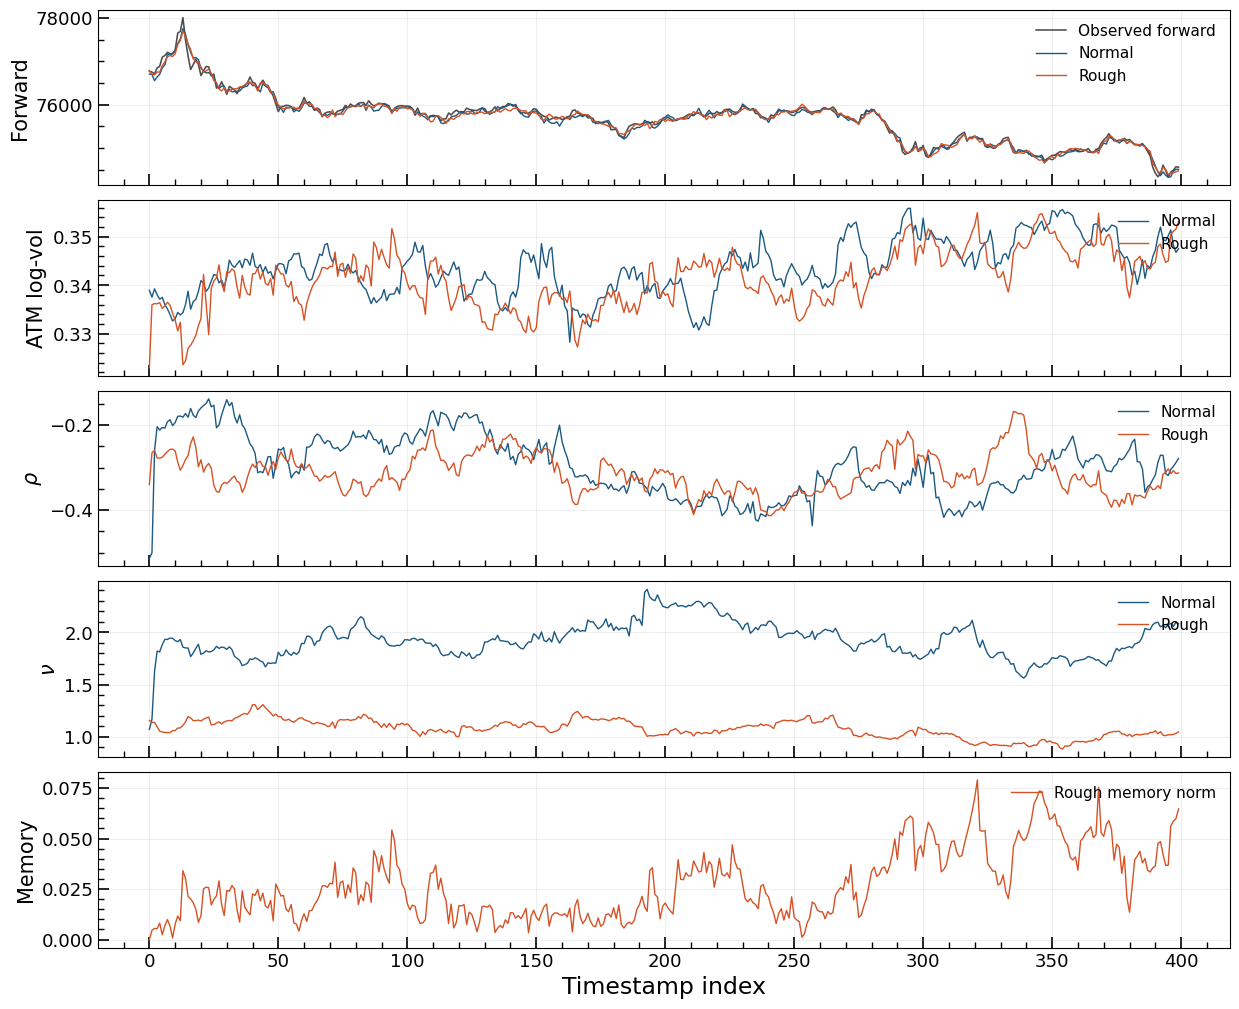

Saved: outputs/comparisons/filtered_state_summaries/figures/filtered_state_primary_seed_123_with_memory.png


In [5]:
primary = state_paths[state_paths["seed"] == PRIMARY_SEED].sort_values(["model", "t_index"])
normal_primary = primary[primary["model"] == "Normal"].sort_values("t_index")
rough_primary = primary[primary["model"] == "Rough"].sort_values("t_index")
forward_primary = primary.groupby("t_index", as_index=False)["F_obs"].mean()

fig, axes = plt.subplots(5, 1, figsize=(12.5, 10.2), sharex=True)

axes[0].plot(forward_primary["t_index"], forward_primary["F_obs"], color=obs_color, linewidth=1.15, label="Observed forward")
axes[0].plot(normal_primary["t_index"], normal_primary["F"], color=normal_color, linewidth=1.0, label="Normal")
axes[0].plot(rough_primary["t_index"], rough_primary["F"], color=rough_color, linewidth=1.0, label="Rough")
axes[0].set_ylabel("Forward", fontsize=15)
axes[0].legend(loc="upper right", frameon=False, fontsize=11)

axes[1].plot(normal_primary["t_index"], normal_primary["atm_logvol_proxy"], color=normal_color, linewidth=1.0, label="Normal")
axes[1].plot(rough_primary["t_index"], rough_primary["atm_logvol_proxy"], color=rough_color, linewidth=1.0, label="Rough")
axes[1].set_ylabel("ATM log-vol", fontsize=15)
axes[1].legend(loc="upper right", frameon=False, fontsize=11)

axes[2].plot(normal_primary["t_index"], normal_primary["rho"], color=normal_color, linewidth=1.0, label="Normal")
axes[2].plot(rough_primary["t_index"], rough_primary["rho"], color=rough_color, linewidth=1.0, label="Rough")
axes[2].set_ylabel(r"$\rho$", fontsize=15)
axes[2].legend(loc="upper right", frameon=False, fontsize=11)

axes[3].plot(normal_primary["t_index"], normal_primary["nu"], color=normal_color, linewidth=1.0, label="Normal")
axes[3].plot(rough_primary["t_index"], rough_primary["nu"], color=rough_color, linewidth=1.0, label="Rough")
axes[3].set_ylabel(r"$\nu$", fontsize=15)
axes[3].legend(loc="upper right", frameon=False, fontsize=11)

if "memory_norm" in rough_primary:
    axes[4].plot(rough_primary["t_index"], rough_primary["memory_norm"], color=rough_color, linewidth=1.0, label="Rough memory norm")
axes[4].set_ylabel("Memory", fontsize=15)
axes[4].set_xlabel("Timestamp index", fontsize=17)
axes[4].legend(loc="upper right", frameon=False, fontsize=11)

for ax in axes:
    ax.grid(alpha=0.20)
    ax.tick_params(axis="both", which="major", direction="in", length=8, width=1.2, labelsize=13)
    ax.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0)
    ax.minorticks_on()

fig.tight_layout()
path = FIGURE_DIR / f"filtered_state_primary_seed_{PRIMARY_SEED}_with_memory.png"
fig.savefig(path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", project_relative(path))


## Rolling-Window State Paths

Plot the filtered states for one rolling-window run.


In [6]:
ROLLING_WINDOW_LABEL = "w301_700"
ROLLING_SEED = 123

rolling_root = OUTPUT_ROOT / "rolling_windows" / ROLLING_WINDOW_LABEL
normal_roll_dir = rolling_root / f"normal_sabr_no_A_RW_seed{ROLLING_SEED}"
rough_roll_dir = rolling_root / f"rough_sabr_logU0_seed{ROLLING_SEED}"
rolling_table_dir = TABLE_DIR / "rolling_windows"
rolling_figure_dir = FIGURE_DIR / "rolling_windows"
rolling_table_dir.mkdir(parents=True, exist_ok=True)
rolling_figure_dir.mkdir(parents=True, exist_ok=True)

normal_roll = pd.read_csv(normal_roll_dir / "filtered_state_path.csv").sort_values("t_index")
rough_roll = pd.read_csv(rough_roll_dir / "filtered_state_path.csv").sort_values("t_index")
forward_roll = (
    pd.read_csv(normal_roll_dir / "selected_observations.csv", usecols=["t_index", "F_obs"])
    .groupby("t_index", as_index=False)["F_obs"]
    .median()
)

window_start_t = int(min(normal_roll["t_index"].min(), rough_roll["t_index"].min()))
for frame in (normal_roll, rough_roll, forward_roll):
    frame["relative_t"] = frame["t_index"] - window_start_t

surface_roll_path = OUTPUT_ROOT / "rolling_windows" / "_comparison" / "surface_roll_event_study_summary.csv"
surface_rolls = pd.read_csv(surface_roll_path)
surface_rolls = surface_rolls[
    surface_rolls["roll_t_index"].between(normal_roll["t_index"].min(), normal_roll["t_index"].max())
].copy()
surface_rolls["relative_t"] = surface_rolls["roll_t_index"] - window_start_t

paired_roll_states = (
    normal_roll[
        ["t_index", "relative_t", "F", "atm_logvol_proxy", "rho", "nu", "fit_price_rmse"]
    ]
    .rename(
        columns={
            "F": "F_normal",
            "atm_logvol_proxy": "atm_logvol_proxy_normal",
            "rho": "rho_normal",
            "nu": "nu_normal",
            "fit_price_rmse": "fit_price_rmse_normal",
        }
    )
    .merge(
        rough_roll[
            [
                "t_index",
                "F",
                "atm_logvol_proxy",
                "rho",
                "nu",
                "memory_norm",
                "fit_price_rmse",
            ]
        ].rename(
            columns={
                "F": "F_rough",
                "atm_logvol_proxy": "atm_logvol_proxy_rough",
                "rho": "rho_rough",
                "nu": "nu_rough",
                "fit_price_rmse": "fit_price_rmse_rough",
            }
        ),
        on="t_index",
        how="inner",
    )
    .merge(forward_roll[["t_index", "F_obs"]], on="t_index", how="left")
)
paired_roll_states["F_diff_rough_minus_normal"] = paired_roll_states["F_rough"] - paired_roll_states["F_normal"]
paired_roll_states["F_error_normal"] = paired_roll_states["F_normal"] - paired_roll_states["F_obs"]
paired_roll_states["F_error_rough"] = paired_roll_states["F_rough"] - paired_roll_states["F_obs"]
paired_roll_states.to_csv(
    rolling_table_dir / f"{ROLLING_WINDOW_LABEL}_seed{ROLLING_SEED}_paired_filtered_states.csv",
    index=False,
)

display(paired_roll_states.head())


,t_index,relative_t,F_normal,atm_logvol_proxy_normal,rho_normal,nu_normal,fit_price_rmse_normal,F_rough,atm_logvol_proxy_rough,rho_rough,nu_rough,memory_norm,fit_price_rmse_rough,F_obs,F_diff_rough_minus_normal,F_error_normal,F_error_rough
0,300,0,75134.457002,0.363401,-0.611636,1.153858,0.001213,74898.480821,0.347876,-0.255093,0.728518,0.000000,0.002162,75061.06,-235.976181,73.397002,-162.579179
1,301,1,75111.375158,0.363070,-0.613364,1.150883,0.002493,74816.947627,0.347582,-0.263801,0.694449,0.004551,0.001294,74821.51,-294.427531,289.865158,-4.562373
2,302,2,74974.445286,0.363314,-0.603455,1.110099,0.001877,74850.928524,0.345703,-0.256975,0.693494,0.014496,0.001167,74780.29,-123.516762,194.155286,70.638524
3,303,3,74915.413931,0.363985,-0.602812,1.106980,0.001209,74847.850057,0.345606,-0.258044,0.685620,0.014468,0.002184,74871.32,-67.563874,44.093931,-23.469943
4,304,4,74942.338381,0.363702,-0.597441,1.105866,0.001770,74894.395391,0.345087,-0.263533,0.692037,0.014880,0.002761,75011.31,-47.942990,-68.971619,-116.914609


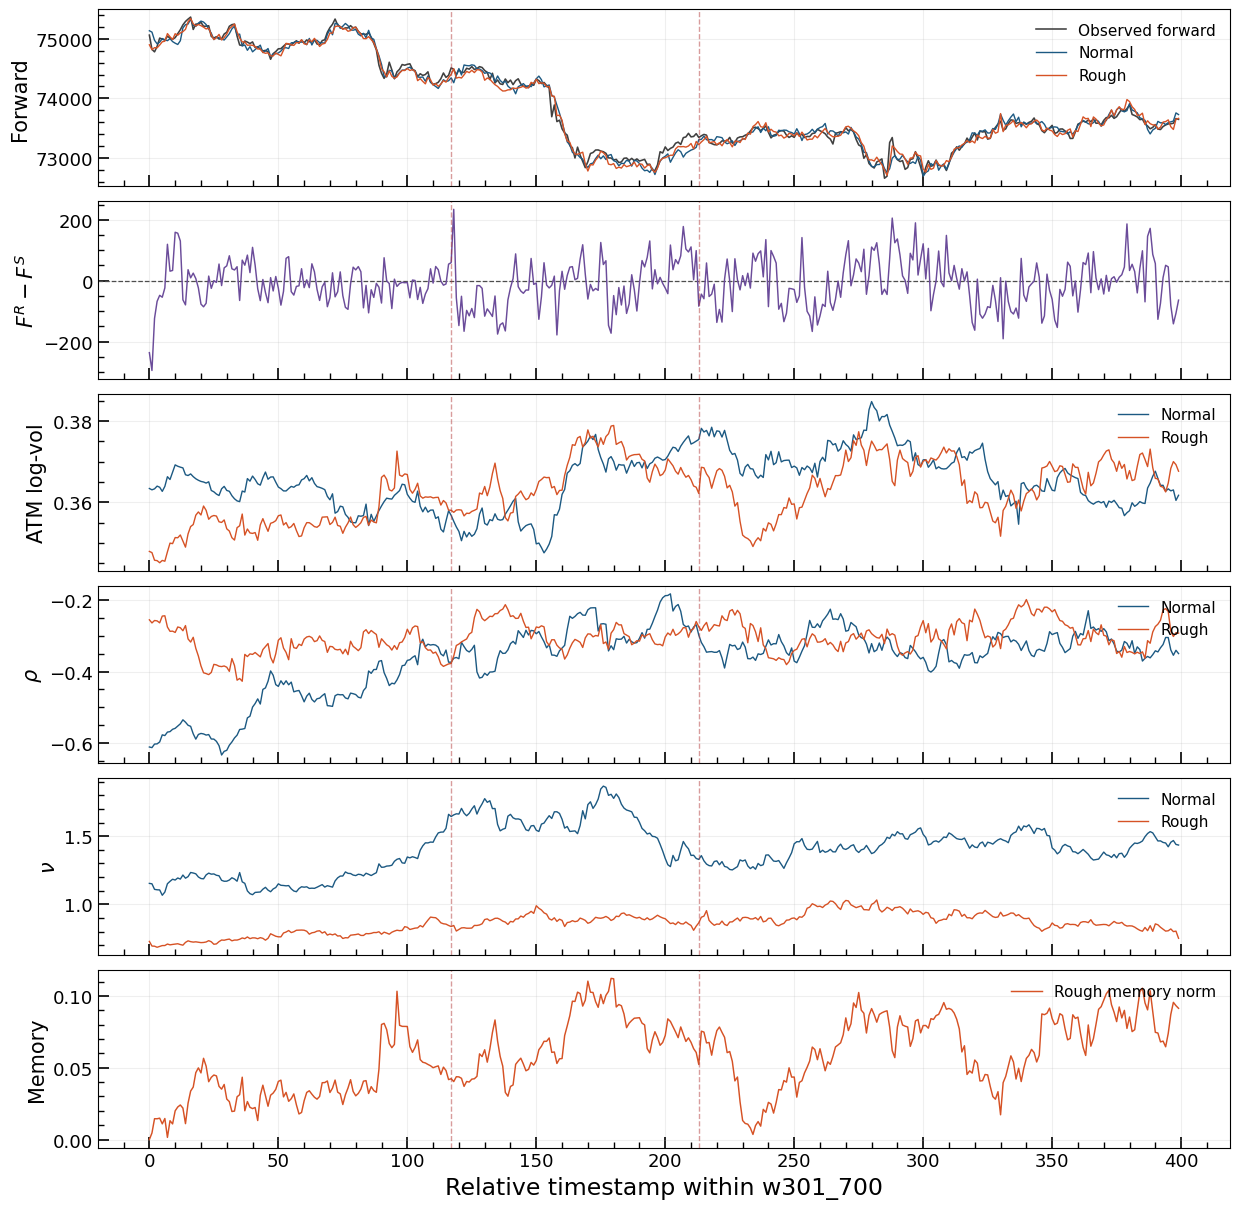

Saved: outputs/comparisons/filtered_state_summaries/figures/rolling_windows/w301_700_seed123_filtered_state_diagnostic.png


In [7]:
normal_color = "#1c5982"
rough_color = "#d65225"
obs_color = "0.25"
diff_color = "#6b4c9a"
roll_color = "#b33a3a"

fig, axes = plt.subplots(6, 1, figsize=(12.5, 12.2), sharex=True)
x = paired_roll_states["relative_t"]

axes[0].plot(x, paired_roll_states["F_obs"], color=obs_color, linewidth=1.15, label="Observed forward")
axes[0].plot(x, paired_roll_states["F_normal"], color=normal_color, linewidth=1.0, label="Normal")
axes[0].plot(x, paired_roll_states["F_rough"], color=rough_color, linewidth=1.0, label="Rough")
axes[0].set_ylabel("Forward", fontsize=15)
axes[0].legend(loc="upper right", frameon=False, fontsize=11)

axes[1].axhline(0.0, color="0.30", linestyle="--", linewidth=0.9)
axes[1].plot(x, paired_roll_states["F_diff_rough_minus_normal"], color=diff_color, linewidth=1.05)
axes[1].set_ylabel(r"$F^R-F^S$", fontsize=15)

axes[2].plot(x, paired_roll_states["atm_logvol_proxy_normal"], color=normal_color, linewidth=1.0, label="Normal")
axes[2].plot(x, paired_roll_states["atm_logvol_proxy_rough"], color=rough_color, linewidth=1.0, label="Rough")
axes[2].set_ylabel("ATM log-vol", fontsize=15)
axes[2].legend(loc="upper right", frameon=False, fontsize=11)

axes[3].plot(x, paired_roll_states["rho_normal"], color=normal_color, linewidth=1.0, label="Normal")
axes[3].plot(x, paired_roll_states["rho_rough"], color=rough_color, linewidth=1.0, label="Rough")
axes[3].set_ylabel(r"$\rho$", fontsize=15)
axes[3].legend(loc="upper right", frameon=False, fontsize=11)

axes[4].plot(x, paired_roll_states["nu_normal"], color=normal_color, linewidth=1.0, label="Normal")
axes[4].plot(x, paired_roll_states["nu_rough"], color=rough_color, linewidth=1.0, label="Rough")
axes[4].set_ylabel(r"$\nu$", fontsize=15)
axes[4].legend(loc="upper right", frameon=False, fontsize=11)

axes[5].plot(x, paired_roll_states["memory_norm"], color=rough_color, linewidth=1.05, label="Rough memory norm")
axes[5].set_ylabel("Memory", fontsize=15)
axes[5].set_xlabel(f"Relative timestamp within {ROLLING_WINDOW_LABEL}", fontsize=17)
axes[5].legend(loc="upper right", frameon=False, fontsize=11)

for ax in axes:
    for _, roll in surface_rolls.iterrows():
        ax.axvline(roll["relative_t"], color=roll_color, linestyle="--", linewidth=1.0, alpha=0.50)
    ax.grid(alpha=0.20)
    ax.tick_params(axis="both", which="major", direction="in", length=8, width=1.2, labelsize=13)
    ax.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0)
    ax.minorticks_on()

fig.tight_layout()
path = rolling_figure_dir / f"{ROLLING_WINDOW_LABEL}_seed{ROLLING_SEED}_filtered_state_diagnostic.png"
fig.savefig(path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", project_relative(path))


## Notes

The figures are descriptive diagnostics for the filtered latent states.
